# Exploração do dataset — produtos de e-commerce

Dataset: *Detailed Products Datasets* (Kaggle) — lista de produtos com marca, nome, descrição e preço.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# tokenizar e carregar_corpus vêm do arquivo app.py (mesma limpeza usada na busca)
from app import tokenizar, carregar_corpus

## 1. Olhando os dados brutos

In [2]:
df = pd.read_csv('products.csv')
print('Linhas e colunas:', df.shape)
df.head()

Linhas e colunas: (4566, 10)


,S.No,BrandName,Product ID,Product Name,Brand Desc,Product Size,Currancy,MRP,SellPrice,Discount
0,1,4711,FR001,Cologne Fragrance,ekw eau de cologne 400 ml,Small,Rs.,3900,3120,20% off
1,2,109f,DRW1,DRW1 - Westernwear-Women,womens v- neck short dress - yellow,"Size:Medium,Small,X-Large,XX-Large",Rs.,1899,569,70% off
2,3,109f,DRW2,DRW2 - Westernwear-Women,womens round neck solid top - black,"Size:Large,Medium,Small,X-Large",Rs.,1499,599,60% off
3,4,109f,DRW3,DRW3 - Westernwear-Women,womens round neck stripe shift dress - red,"Size:Medium,Small",Rs.,1599,639,60% off
4,5,109f,DRW4,DRW4 - Westernwear-Women,womens round neck solid high low top - black,"Size:Large,Medium,Small,X-Large",Rs.,1199,479,60% off


**O que temos:** `BrandName` (marca), `Product Name` (código + categoria), `Brand Desc` (descrição — o texto mais rico), `MRP` (preço de tabela), `SellPrice` (preço de venda) e `Discount`.

Para a **busca** vamos usar só o texto: marca + categoria + descrição. Preços e tamanhos não entram na busca.

In [3]:
print('Valores vazios por coluna:')
print(df.isna().sum())
print('\nLinhas totalmente repetidas:', df.duplicated().sum())

Valores vazios por coluna:
S.No             0
BrandName        0
Product ID       0
Product Name     0
Brand Desc       0
Product Size     0
Currancy         0
MRP             13
SellPrice        0
Discount         0
dtype: int64

Linhas totalmente repetidas: 0


Só a coluna `MRP` tem valores vazios, e ela não é usada na busca. Nada a corrigir.

## 2. Preços

count     4566.0
mean      2005.0
std       2260.0
min         89.0
25%        749.0
50%       1379.0
75%       2299.0
max      25995.0
Name: SellPrice, dtype: float64


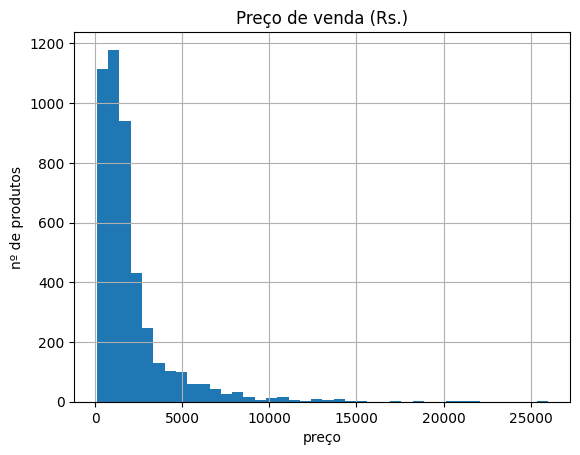

In [4]:
print(df['SellPrice'].describe().round(0))
df['SellPrice'].hist(bins=40)
plt.title('Preço de venda (Rs.)'); plt.xlabel('preço'); plt.ylabel('nº de produtos'); plt.show()

A maioria dos produtos é barata, com poucos itens muito caros (o máximo passa de Rs. 25.000). Não afeta a busca por texto, só ajuda a entender o catálogo.

## 3. Marcas e categorias

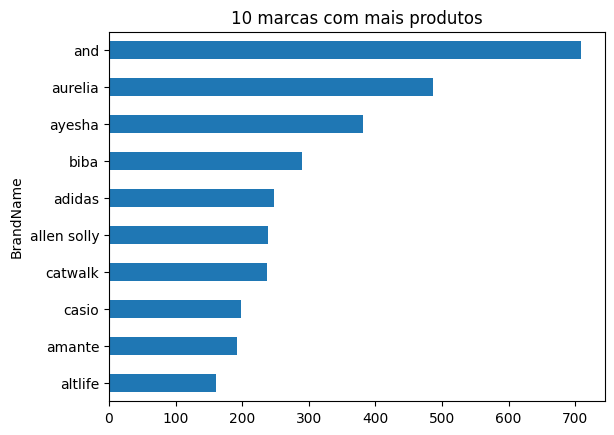

In [5]:
df['BrandName'].value_counts().head(10).plot(kind='barh')
plt.title('10 marcas com mais produtos'); plt.gca().invert_yaxis(); plt.show()

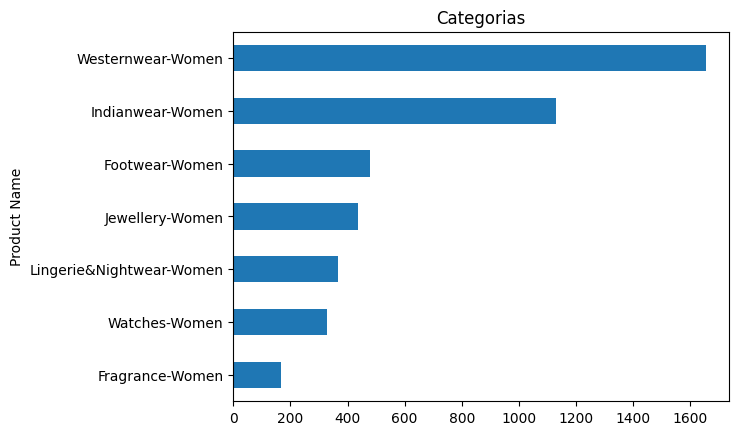

In [6]:
categoria = df['Product Name'].str.split(' - ').str[-1]
categoria.value_counts().head(7).plot(kind='barh')
plt.title('Categorias'); plt.gca().invert_yaxis(); plt.show()

O catálogo é de moda feminina (roupas ocidentais e indianas, calçados, joias, lingerie), relógios e perfumes.

## 4. O texto que será indexado (corpus)

`carregar_corpus()` junta marca + categoria + descrição, tira o código do produto, remove textos muito curtos e **produtos repetidos** (mesma marca, categoria e descrição, mas com código/tamanho diferente).

In [7]:
corpus = carregar_corpus()
print('Produtos no dataset:', len(df), '| Documentos no corpus (sem repetidos):', len(corpus))
corpus[['texto']].head(8)

Produtos no dataset: 4566 | Documentos no corpus (sem repetidos): 4156


,texto
0,ayesha . Jewellery-Women . womens white glitte...
1,casio . Watches-Women . womens ba-120sp-1adr (...
2,biba . Indianwear-Women . printed rayon round ...
3,cover story . COVER Westernwear-Women . stripe...
4,catwalk . Footwear-Women . womens metal accent...
5,aurelia . Indianwear-Women . printed polyester...
6,109f . Westernwear-Women . womens solid casual...
7,aurelia . Indianwear-Women . printed cotton ma...


Sobraram **4.156 documentos** — dentro do intervalo de 1.000 a 10.000 pedido no trabalho. Cada produto é um documento.

count    4156.0
mean       13.1
std         1.9
min         7.0
25%        12.0
50%        13.0
75%        14.0
max        23.0
Name: texto, dtype: float64


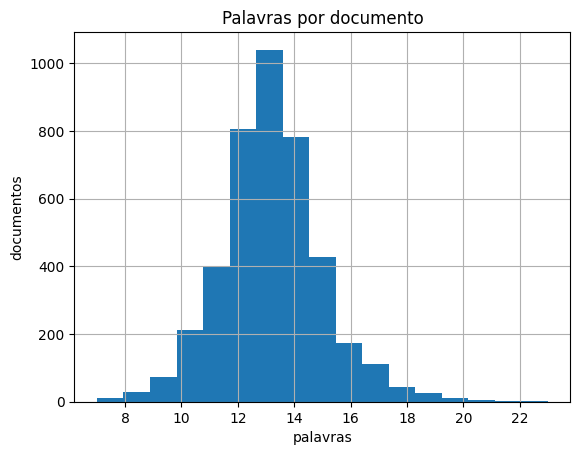

In [8]:
palavras = corpus['texto'].str.split().str.len()
print(palavras.describe().round(1))
palavras.hist(bins=17)
plt.title('Palavras por documento'); plt.xlabel('palavras'); plt.ylabel('documentos'); plt.show()

Os documentos são **curtos e de tamanho parecido** (~13 palavras). Isso importa para o BM25: como quase não há documentos longos, a correção por tamanho (`b`) tem pouco efeito aqui.

## 5. Vocabulário: quais palavras aparecem mais?

Contamos em **quantos documentos** cada palavra aparece (depois de limpar o texto).

Palavras diferentes (vocabulário): 1512
Palavras que aparecem em só 1 documento: 678


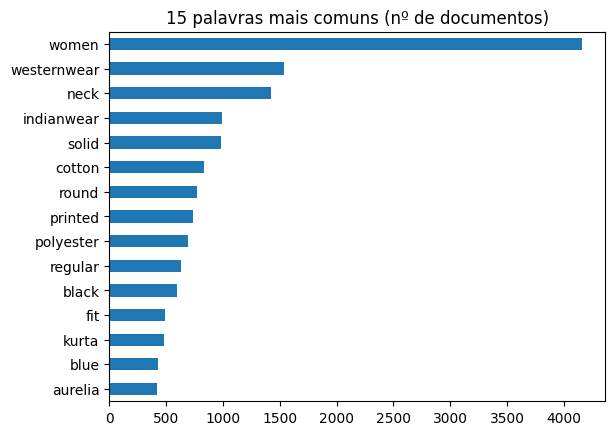

In [9]:
docs_por_palavra = Counter(p for texto in corpus['texto'] for p in set(tokenizar(texto)))
print('Palavras diferentes (vocabulário):', len(docs_por_palavra))
print('Palavras que aparecem em só 1 documento:', sum(1 for v in docs_por_palavra.values() if v == 1))

top = pd.Series(dict(docs_por_palavra.most_common(15)))
top.plot(kind='barh'); plt.gca().invert_yaxis()
plt.title('15 palavras mais comuns (nº de documentos)'); plt.show()

## 6. O que aprendemos

- O corpus tem **4.156 documentos curtos**, em inglês, sobre moda e perfumes.
- A palavra **`women` aparece em quase todos** os documentos: ela não ajuda a diferenciar nada. É exatamente o que o **IDF** faz — dá peso baixo para palavras comuns e alto para raras.
- Muitas palavras são raras (centenas aparecem em 1 só documento): boas para testar buscas por **termo raro**.
- Palavras como `dress`, `kurta` e `cotton` são frequentes (centenas de produtos): boas para testar **termo frequente**.
- Alguns produtos usam palavras diferentes para a mesma coisa (`perfume`, `edp`, `fragrance`): bom para testar **sinônimos** com o LSA.
